In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data/train.csv')

In [4]:
df.shape

(404290, 6)

In [5]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [6]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [9]:
new_df = df.sample(50000, random_state=2) # as there are more than 400,000 rows for now we are considering 50,000

In [10]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [11]:
new_df.duplicated().sum()

np.int64(0)

In [12]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [14]:
new_df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
330249,330249,456999,457000,Is it impossible to be republican and gay?,Is gay marriage a losing issue for Republicans?,0
309375,309375,433347,433348,How can I increase traffic on my online shoppi...,How can I increase traffic on my online store?,0
256148,256148,371184,371185,What's the cleanest diet possible?,What is the cleanest diet?,1
61677,61677,107633,7966,What are impacts of demonetization on the Indi...,What are the impacts on Indian Rupee value aft...,0
25774,25774,48024,8399,What do pakisthani people think about India?,What do people think about India?,0
289298,289298,14869,41113,What is the best Harry Potter movie and why? I...,Which is your favourite Harry Potter movie and...,1
291792,291792,413288,413289,Will i3-6100 processor be good for gaming for ...,Is the i3 6100 fine for gaming wtih a gtx 970?,0
332572,332572,459568,459569,What Is crisis intervention?,What is a crisis intervention model?,0
346956,346956,475362,475363,What are the duties of a quality controle engi...,How do I work better as a quality control engi...,0
142472,142472,158365,225934,How do accelerators make a profit?,How do accelleraters make profit?,1


is_duplicate
0    31601
1    18399
Name: count, dtype: int64
is_duplicate
0    63.202
1    36.798
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

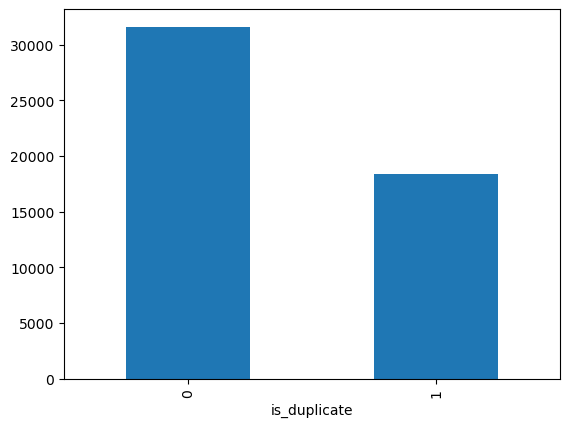

In [17]:
print(new_df['is_duplicate'].value_counts())
print((new_df['is_duplicate'].value_counts() / new_df['is_duplicate'].count()) * 100)
new_df['is_duplicate'].value_counts().plot(kind='bar')

As we can see the dataset is imbalance, but in real life we have to make our dataset balanced

In [18]:
qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print('Number of unique questions : ', np.unique(qid).shape[0])
x = qid.value_counts() > 1
print('Number of question getting repetead ', x[x].shape[0])
# .shpae[0] will return number of items

Number of unique questions :  88945
Number of question getting repetead  7384


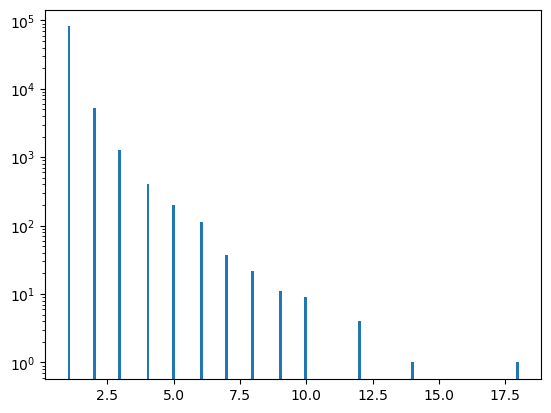

In [20]:
# Repetead question histogram
plt.hist(qid.value_counts().values, bins=160)
plt.yscale('log')
plt.show()

#### Feature Engineering
We can do some feature engineering, we can include this 7 features

- q1 len : char length(question lenght) of q1
- q2 len : char length(question length) of q2
- q1 words : num of words in q1 (how many words in q1)
- q2 words : num of words in q2
- word common : num of common unique words
- words total : Total num of words in q1 + Total num of words in q2
- word share : Word common / word total

In [21]:
# add feature : q1 & q2 len
new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [22]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50


In [23]:
# add feature : num of q1 & q1 words
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))

In [24]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9


In [25]:
# add feature : word common
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

new_df['word_common'] = new_df.apply(common_words, axis=1)
# by default axis = 0 which indicates columns and axis = 1 indicates rows

In [26]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3


In [27]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

new_df['word_total'] = new_df.apply(total_words, axis=1)

In [28]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13


In [29]:
new_df['word_share'] = round(new_df['word_common'] / new_df['word_total'], 2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24,0.46
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23,0.30
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34,0.06
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32,0.00
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13,0.23


Minimum characters :  1
Maximum characters :  391
Average num of characters :  59.4183


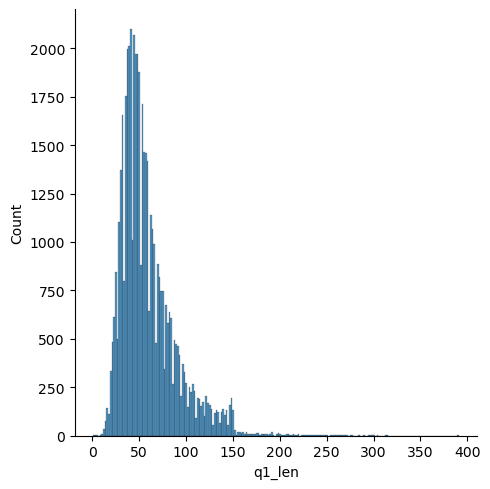

In [33]:
# analysis of features
sns.displot(new_df['q1_len'])
print('Minimum characters : ', new_df['q1_len'].min())
print('Maximum characters : ', new_df['q1_len'].max())
print('Average num of characters : ', (new_df['q1_len'].mean()))

minimum characters :  6
Maximum characters :  1151
Average characters :  60.0878


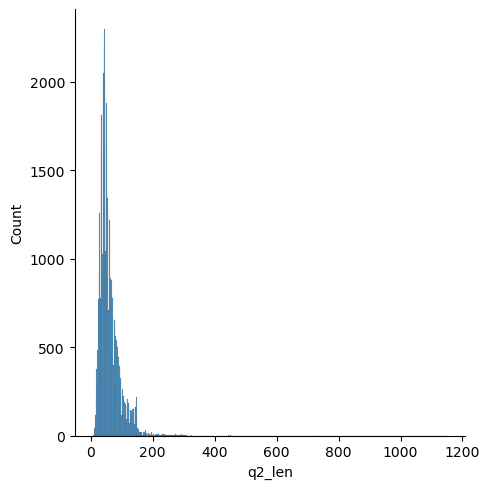

In [36]:
sns.displot(new_df['q2_len'])
print('minimum characters : ', new_df['q2_len'].min())
print('Maximum characters : ', new_df['q2_len'].max())
print('Average characters : ', new_df['q2_len'].mean())

Minimum words :  1
Maximum words :  72
Average num of words :  10


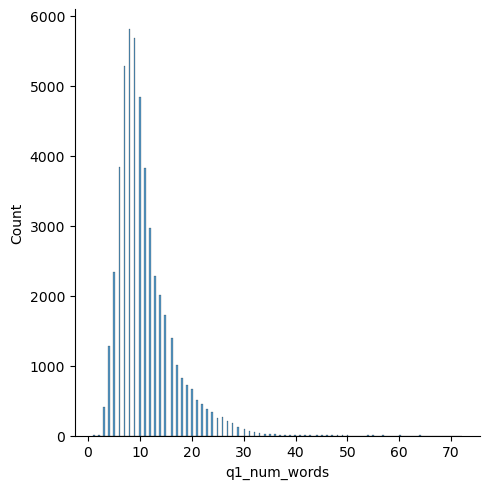

In [38]:
sns.displot(new_df['q1_num_words'])
print('Minimum words : ', new_df['q1_num_words'].min())
print('Maximum words : ', new_df['q1_num_words'].max())
print('Average num of words : ', int(new_df['q1_num_words'].mean()))

Minimum words :  1
Maximum words :  237
Average num of words :  11


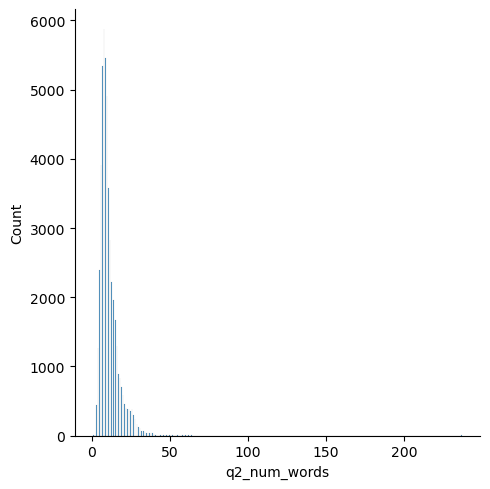

In [39]:
sns.displot(new_df['q2_num_words'])
print('Minimum words : ', new_df['q2_num_words'].min())
print('Maximum words : ', new_df['q2_num_words'].max())
print('Average num of words : ', int(new_df['q2_num_words'].mean()))

C:\Users\Labib\AppData\Local\Temp\ipykernel_12036\3839859553.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'], label = 'non duplicate')
C:\Users\Labib\AppData\Local\Temp\ipykernel_12036\3839859553.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.di

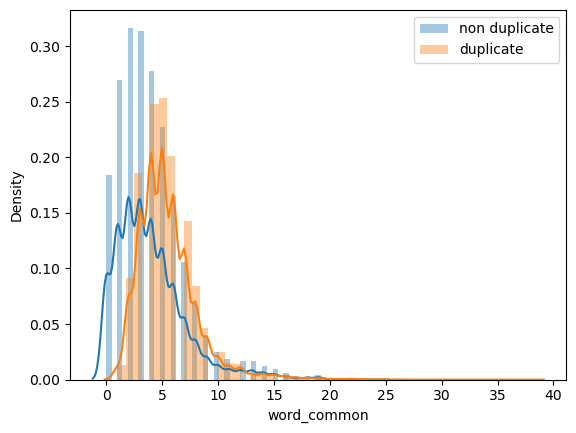

In [44]:
# common words
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'], label = 'non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_common'], label = 'duplicate')
plt.legend()
plt.show()

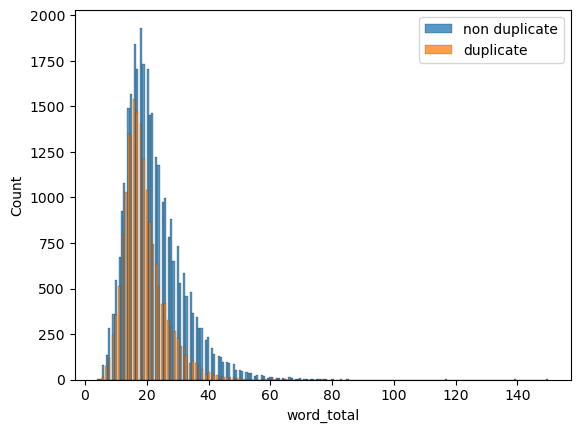

In [45]:
# common words
sns.histplot(new_df[new_df['is_duplicate'] == 0]['word_total'], label = 'non duplicate')
sns.histplot(new_df[new_df['is_duplicate'] == 1]['word_total'], label = 'duplicate')
plt.legend()
plt.show()

C:\Users\Labib\AppData\Local\Temp\ipykernel_12036\3239371719.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'], label = 'non duplicate')
C:\Users\Labib\AppData\Local\Temp\ipykernel_12036\3239371719.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dis

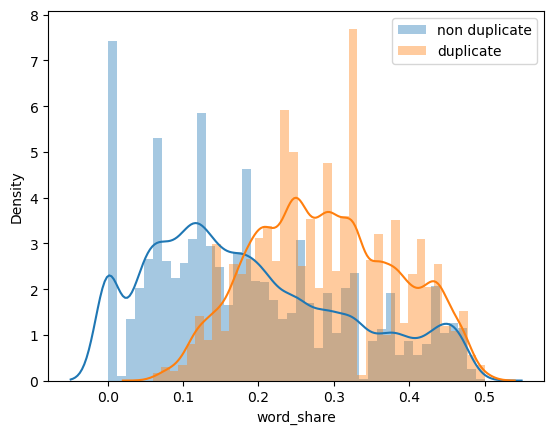

In [46]:
# word share
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'], label = 'non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_share'], label = 'duplicate')
plt.legend()
plt.show()

In [47]:
ques_df = new_df[['question1', 'question2']]
ques_df.head()

,question1,question2
398782,What is the best marketing automation tool for...,What is the best marketing automation tool for...
115086,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...
327711,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...
367788,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...
151235,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...


In [48]:
final_df = new_df.drop(columns=['id', 'qid1', 'qid2', 'question1', 'question2'])
print(final_df.shape)
final_df.head()

(50000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
398782,1,76,77,12,12,11,24,0.46
115086,0,49,57,12,15,7,23,0.30
327711,0,105,120,25,17,2,34,0.06
367788,0,59,146,12,30,0,32,0.00
151235,0,35,50,5,9,3,13,0.23


In [49]:
from sklearn.feature_extraction.text import CountVectorizer
# merge text
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

In [50]:
temp_df1 = pd.DataFrame(q1_arr, index = ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index = ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis = 1)
temp_df.shape

(50000, 6000)

In [51]:
final_df = pd.concat([final_df, temp_df], axis = 1)
print(final_df.shape)
final_df.head()

(50000, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,76,77,12,12,11,24,0.46,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,49,57,12,15,7,23,0.30,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,105,120,25,17,2,34,0.06,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,59,146,12,30,0,32,0.00,0,0,...,0,0,1,0,0,0,0,0,0,0
151235,0,35,50,5,9,3,13,0.23,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values, final_df.iloc[:,0].values, test_size=0.2, random_state=1)

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.7722

In [56]:
pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
    --------------------------------------- 1.0/56.8 MB 7.0 MB/s eta 0:00:09
   - -------------------------------------- 1.6/56.8 MB 3.0 MB/s eta 0:00:19
   - -------------------------------------- 1.8/56.8 MB 3.3 MB/s eta 0:00:17
   - -------------------------------------- 2.6/56.8 MB 3.2 MB/s eta 0:00:18
   -- ------------------------------------- 3.1/56.8 MB 2.6 MB/s eta 0:00:21
   -- ------------------------------------- 3.7/56.8 MB 2.8 MB/s eta 0:00:19
   -- ------------------------------------- 4.2/56.8 MB 2.7 MB/s eta 0:00:20
   --- ------------------------------------ 4.7/56.8 MB 2.8 MB/s eta 0:00:19
   --- ------------------------------------ 5.5/56.8 MB 2.7 MB/s eta 0:00:19
   ---- ----------------------------------- 5.8/56.8 MB 2.7 MB/s eta 0:00:19
   ---- ----------------------------------- 6.3/56.8 MB 2.7 MB/s eta 0:00:20
   ---- -----

In [57]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test, y_pred)

0.7683